In [1]:
import sys
sys.path.append('../../Codes/library/')

import scipy.special as sc
from funcs import*

plt.rcParams['text.usetex'] = True
Text_files_path = '/Users/robertomorantovar/Dropbox/Research/Immune_system/'

%autosave 60

Autosaving every 60 seconds


In [2]:
def sample_activation_times_nhpp(N0, u0, lambda_A, rng):
    """
    First-event times for NHPP with intensity u(t) = u0 * exp(lambda_A * t).
    Exact sampling via inverse transform.
    """
    # E ~ Exp(1)
    E = rng.exponential(scale=1.0, size=N0)
    # T = (1/lambda_A) * log(1 + (lambda_A/u0)*E)
    T = (1.0 / lambda_A) * np.log1p((lambda_A / u0) * E)
    return T

In [18]:
def simulate_clone_sizes(N0, u0, lambda_A, lambda_B, seed=None, integer_output=False):
    """
    N0 founder cells.
    Each activates at first event of NHPP with intensity u(t)=u0*exp(lambda_A t).
    After activation, clone grows deterministically: exp(lambda_B * (T_end - t_act)).
    Stop when all are activated (T_end = max activation time).
    Return final clone sizes per founder.
    """
    if N0 <= 0:
        raise ValueError("N0 must be positive.")
    if u0 <= 0:
        raise ValueError("u0 must be > 0.")
    if lambda_A <= 0:
        raise ValueError("lambda_A must be > 0.")
    if lambda_B < 0:
        raise ValueError("lambda_B must be >= 0.")

    rng = np.random.default_rng()

    t_act = sample_activation_times_nhpp(N0, u0, lambda_A, rng)
    T_end = float(np.max(t_act))

    sizes = np.exp(lambda_B * (T_end - t_act))

    if integer_output:
        sizes = np.rint(sizes).astype(int)
        sizes = np.maximum(sizes, 1)

    return t_act, T_end, sizes


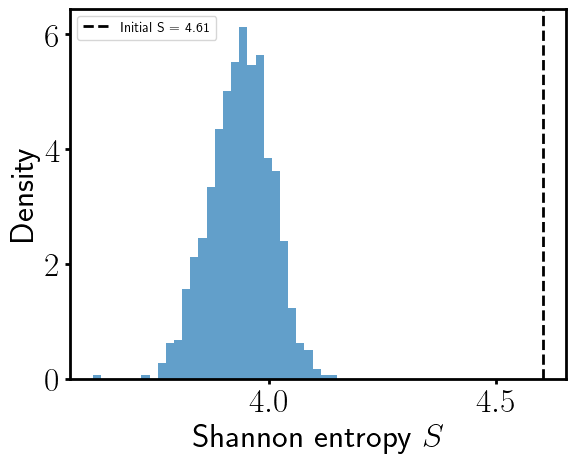

In [40]:
# Example
N0 = 100
u0 = 0.05        # baseline intensity scale
lambda_A = 0.4   # intensity exponent
lambda_B = 0.6   # growth rate after activation

# initial (uniform) entropy: all N0 clones equal -> S0 = log(N0)
S0 = np.log(N0)

Ss = []
N_ens = 1000
for _ in range(N_ens):
    t_act, T_end, sizes = simulate_clone_sizes(N0, u0, lambda_A, lambda_B)
    x = sizes/np.sum(sizes)
    S = -np.sum(x*np.log(x))
    Ss.append(S)

fig, ax = plt.subplots()
ax.hist(Ss, bins=30, density=True, alpha=0.7)
ax.axvline(S0, color='k', linestyle='--', linewidth=2, label=f'Initial S = {S0:.2f}')
# plot a vertical dashed line showing the initial entropy
my_plot_layout(ax=ax)
ax.set_xlabel('Shannon entropy $S$')
ax.set_ylabel('Density')
# ax.set_title(f'N0={N0}, u0={u0}, lambda_A={lambda_A}, lambda_B={lambda_B}')
ax.legend()

plt.show()